# Modeling

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

from data_prep import load_run_data, build_global_init_map, build_run_trajectory, build_neighbors_index, _numeric_agent_key
from analysis_utils import (
    evaluate_validation_model,
    align_rollout_pair,
    plot_mean_per_timestep,
    plot_variance_per_timestep,
    plot_wasserstein_distance_per_timestep,
    plot_observed_trajectories,
    plot_predicted_vs_observed,
    plot_box_per_timestep,
    plot_violin_per_timestep,
    compute_mean_prediction_error,
    compute_max_prediction_error,
)
from adjency_based.degroot import (
    fit_degroot_adjacency_scalar,
    degroot_rollout_prediction,
)
from adjency_based.friedkin_johnsen import (
    fit_friedkin_johnsen_adjacency,
    select_friedkin_johnsen_adjacency_lambdas,
    friedkin_johnsen_adjacency_rollout,
)
from adjency_based.homophily import (
    fit_homophily,
    rollout_with_homophily,
    fit_homophily_stubborness,
    rollout_with_homophily_stubborness,
    fit_homophily_friedkin_johnsen,
    rollout_with_homophily_friedkin_johnsen,
)

ROOT = Path('..').resolve()
CLEAN = ROOT / 'runs' / 'llama3.1' / 'climate' / 'train'

PARAMS = {
    'target_agent_fraction': 0.4,
    'constrain_messages': 150,
    'rollout_horizon_cap': 20,
    'validation_horizon': 8,
}

RUN_DIRS = sorted([p for p in CLEAN.iterdir() if p.is_dir()])
print('Project root:', ROOT)
print('Cleaned data:', CLEAN)
print('Runs found:', len(RUN_DIRS))
for r in RUN_DIRS[:26]:
    print(' ', r.name)

Project root: /Users/samuelli/Documents/code/llm/llm-network/modeling
Cleaned data: /Users/samuelli/Documents/code/llm/llm-network/modeling/runs/llama3.1/climate/train
Runs found: 24
  run_20260506-223938
  run_20260506-225959
  run_20260506-232018
  run_20260506-234038
  run_20260507-000056
  run_20260507-002116
  run_20260507-004135
  run_20260507-010156
  run_20260507-012214
  run_20260507-014232
  run_20260507-020250
  run_20260507-022306
  run_20260507-024322
  run_20260507-030339
  run_20260507-032355
  run_20260507-034414
  run_20260507-040436
  run_20260507-042451
  run_20260507-044507
  run_20260507-050523
  run_20260507-052538
  run_20260507-054555
  run_20260507-060615
  run_20260507-062633


## Data Construction

- Each run is mapped to a shared global agent index.
- Trajectories are built from the run data with the same preprocessing used in the baseline notebook.
- Neighbor sets are preserved per run for the homophily kernel.

In [2]:
RUN_DATA = {r.name: load_run_data(r) for r in RUN_DIRS}
GLOBAL_AGENT_IDS = sorted({a for d in RUN_DATA.values() for a in d['agent_ids']}, key=_numeric_agent_key)
N = len(GLOBAL_AGENT_IDS)

GLOBAL_INIT_BY_AGENT = build_global_init_map(RUN_DATA, GLOBAL_AGENT_IDS)
RUN_TRAJ_AND_MASK = {
    rn: build_run_trajectory(
        d,
        GLOBAL_AGENT_IDS,
        target_agent_fraction=PARAMS['target_agent_fraction'],
        return_post_mask=True,
        constrain_messages=PARAMS['constrain_messages'],
    )
    for rn, d in RUN_DATA.items()
}
RUN_TRAJ = {rn: tm[0] for rn, tm in RUN_TRAJ_AND_MASK.items()}
RUN_POST_MASK = {rn: tm[1] for rn, tm in RUN_TRAJ_AND_MASK.items()}
RUN_NEIGHBORS = {rn: build_neighbors_index(d, GLOBAL_AGENT_IDS) for rn, d in RUN_DATA.items()}

print('Global agent count:', N)
print('Global init priors available:', len(GLOBAL_INIT_BY_AGENT))
for rn in sorted(RUN_TRAJ.keys()):
    tr = RUN_TRAJ[rn]
    print(f'{rn}: trajectory shape={tr.shape}, horizon={tr.shape[0] - 1}')

Global agent count: 30
Global init priors available: 30
run_20260506-223938: trajectory shape=(11, 30), horizon=10
run_20260506-225959: trajectory shape=(12, 30), horizon=11
run_20260506-232018: trajectory shape=(12, 30), horizon=11
run_20260506-234038: trajectory shape=(12, 30), horizon=11
run_20260507-000056: trajectory shape=(12, 30), horizon=11
run_20260507-002116: trajectory shape=(12, 30), horizon=11
run_20260507-004135: trajectory shape=(12, 30), horizon=11
run_20260507-010156: trajectory shape=(12, 30), horizon=11
run_20260507-012214: trajectory shape=(11, 30), horizon=10
run_20260507-014232: trajectory shape=(13, 30), horizon=12
run_20260507-020250: trajectory shape=(13, 30), horizon=12
run_20260507-022306: trajectory shape=(11, 30), horizon=10
run_20260507-024322: trajectory shape=(13, 30), horizon=12
run_20260507-030339: trajectory shape=(12, 30), horizon=11
run_20260507-032355: trajectory shape=(11, 30), horizon=10
run_20260507-034414: trajectory shape=(14, 30), horizon=13


In [3]:
print('RUN_TRAJ post-rate audit (posts / N per time slice, from RUN_POST_MASK)')
print('N =', N)
all_post_fracs = []
for rn in sorted(RUN_TRAJ.keys()):
    tr = np.asarray(RUN_TRAJ[rn], dtype=float)
    pm = np.asarray(RUN_POST_MASK[rn], dtype=bool)
    per_slice_post_frac = pm.mean(axis=1)
    all_post_fracs.extend(per_slice_post_frac.tolist())
    print(f"{rn}: post_mean={np.mean(per_slice_post_frac):.3f}, post_min={np.min(per_slice_post_frac):.3f}, post_max={np.max(per_slice_post_frac):.3f}, slices={tr.shape[0]}")

if all_post_fracs:
    print('\nGlobal RUN_TRAJ post-rate summary:')
    print(f"mean={np.mean(all_post_fracs):.3f}, median={np.median(all_post_fracs):.3f}, min={np.min(all_post_fracs):.3f}, max={np.max(all_post_fracs):.3f}, total_slices={len(all_post_fracs)}")

RUN_TRAJ post-rate audit (posts / N per time slice, from RUN_POST_MASK)
N = 30
run_20260506-223938: post_mean=0.385, post_min=0.200, post_max=0.533, slices=11
run_20260506-225959: post_mean=0.328, post_min=0.200, post_max=0.467, slices=12
run_20260506-232018: post_mean=0.325, post_min=0.167, post_max=0.467, slices=12
run_20260506-234038: post_mean=0.342, post_min=0.200, post_max=0.500, slices=12
run_20260507-000056: post_mean=0.347, post_min=0.067, post_max=0.533, slices=12
run_20260507-002116: post_mean=0.339, post_min=0.100, post_max=0.567, slices=12
run_20260507-004135: post_mean=0.333, post_min=0.067, post_max=0.500, slices=12
run_20260507-010156: post_mean=0.344, post_min=0.033, post_max=0.500, slices=12
run_20260507-012214: post_mean=0.382, post_min=0.200, post_max=0.500, slices=11
run_20260507-014232: post_mean=0.310, post_min=0.033, post_max=0.433, slices=13
run_20260507-020250: post_mean=0.326, post_min=0.133, post_max=0.533, slices=13
run_20260507-022306: post_mean=0.361, pos

In [4]:
degroot_adj = fit_degroot_adjacency_scalar(RUN_TRAJ, RUN_NEIGHBORS)
GLOBAL_W = degroot_adj['W_blocks']
DEGROOT_GAMMA = degroot_adj['gamma']
DEGROOT_POOL_MSE = degroot_adj['mse_pool']

# FJ adjacency model: select lambdas by grid, then fit gamma+bias.
LAMBDA_GRID = np.linspace(0.0, 0.6, 13)
BEST_FJ_ADJ, FJ_ADJ_GRID = select_friedkin_johnsen_adjacency_lambdas(
    RUN_TRAJ,
    RUN_NEIGHBORS,
    LAMBDA_GRID,
)
FJ_ADJ_L1 = BEST_FJ_ADJ['lambda1']
FJ_ADJ_L2 = BEST_FJ_ADJ['lambda2']
FJ_ADJ_FIT = fit_friedkin_johnsen_adjacency(
    RUN_TRAJ,
    RUN_NEIGHBORS,
    FJ_ADJ_L1,
    FJ_ADJ_L2,
)
FJ_ADJ_GAMMA = FJ_ADJ_FIT['gamma']
FJ_ADJ_BIAS = FJ_ADJ_FIT['bias']
FJ_ADJ_W = FJ_ADJ_FIT['W_blocks']
FJ_ADJ_POOL_MSE = FJ_ADJ_FIT['mse_pool']

## Homophily

In [5]:
HOMOPHILY = fit_homophily(RUN_TRAJ, RUN_NEIGHBORS, gamma0=1.0)
HOMOPHILY_A = HOMOPHILY['Abar_blocks']
HOMOPHILY_GAMMA = HOMOPHILY['gamma']
HOMOPHILY_LAMBDA = HOMOPHILY["lambda"]

print('Homophily fit')
print('gamma:', HOMOPHILY_GAMMA)
print('Global pooled MSE loss:', HOMOPHILY['mse_pool'])
print('lambda:', HOMOPHILY_LAMBDA)

Homophily fit
gamma: 1.2832290742018846
Global pooled MSE loss: 0.02184815323777711
lambda: 0.6520847188558382


In [6]:
BEST_HOMO_FJ = fit_homophily_friedkin_johnsen(
    RUN_TRAJ, 
    RUN_NEIGHBORS, 
    gamma0=HOMOPHILY_GAMMA
)

homo_fj_rows = [{
    "lambda1": BEST_HOMO_FJ["lambda1"],
    "lambda_self":BEST_HOMO_FJ["lambda_self"],
    "gamma": BEST_HOMO_FJ["gamma"],
    "mse_pool": BEST_HOMO_FJ["mse_pool"],
    "success": BEST_HOMO_FJ["success"],
    "nit": BEST_HOMO_FJ["nit"],
    "status": BEST_HOMO_FJ["status"],
}]

HOMO_FJ_LAMBDA_TABLE = pd.DataFrame(homo_fj_rows).sort_values("mse_pool").reset_index(drop=True)

print("Best homophily+friedkin-johnsen fit (inner lambda optimization + outer gamma search)")
print("lambda1:", BEST_HOMO_FJ["lambda1"])
print("lambda_self:", BEST_HOMO_FJ["lambda_self"])
print("gamma:", BEST_HOMO_FJ["gamma"])
print("mse_pool:", BEST_HOMO_FJ["mse_pool"])
print("gamma grid tested:", len(BEST_HOMO_FJ.get("gamma_grid", [])))

HOMO_FJ_A = BEST_HOMO_FJ["Abar_blocks"]
HOMO_FJ_GAMMA = BEST_HOMO_FJ["gamma"]
HOMO_FJ_L1 = BEST_HOMO_FJ["lambda1"]
HOMO_FJ_LSELF = BEST_HOMO_FJ["lambda_self"]

HOMO_FJ_LAMBDA_TABLE.head(10)

Best homophily+friedkin-johnsen fit (inner lambda optimization + outer gamma search)
lambda1: 0.0053711433552614775
lambda_self: 0.6465736105695495
gamma: 1.3000193408785365
mse_pool: 0.021843031730414738
gamma grid tested: 326


,lambda1,lambda_self,gamma,mse_pool,success,nit,status
0,0.005371,0.646574,1.300019,0.021843,True,50,optimal


In [7]:
BEST_HOMO_STUB = fit_homophily_stubborness(
    RUN_TRAJ,
    RUN_NEIGHBORS,
    gamma0=HOMOPHILY_GAMMA,
)

homo_stub_rows = [{
    "lambda1": BEST_HOMO_STUB["lambda1"],
    "lambda2": BEST_HOMO_STUB["lambda2"],
    "lambda_self": BEST_HOMO_STUB["lambda_self"],
    "gamma": BEST_HOMO_STUB["gamma"],
    "bias": BEST_HOMO_STUB["bias"],
    "mse_pool": BEST_HOMO_STUB["mse_pool"],
    "success": BEST_HOMO_STUB["success"],
    "nit": BEST_HOMO_STUB["nit"],
    "status": BEST_HOMO_STUB["status"],
}]

HOMO_STUB_LAMBDA_TABLE = pd.DataFrame(homo_stub_rows).sort_values("mse_pool").reset_index(drop=True)

print("Best homophily+stubbornness fit (inner lambda optimization + outer gamma search)")
print("lambda1:", BEST_HOMO_STUB["lambda1"])
print("lambda2:", BEST_HOMO_STUB["lambda2"])
print("lambda_self:", BEST_HOMO_STUB["lambda_self"])
print("gamma:", BEST_HOMO_STUB["gamma"])
print("bias:", BEST_HOMO_STUB["bias"])
print("mse_pool:", BEST_HOMO_STUB["mse_pool"])
print("gamma grid tested:", len(BEST_HOMO_STUB.get("gamma_grid", [])))

HOMO_STUB_A = BEST_HOMO_STUB["Abar_blocks"]
HOMO_STUB_GAMMA = BEST_HOMO_STUB["gamma"]
HOMO_STUB_BIAS = BEST_HOMO_STUB["bias"]
HOMO_STUB_L1 = BEST_HOMO_STUB["lambda1"]
HOMO_STUB_L2 = BEST_HOMO_STUB["lambda2"]
HOMO_STUB_LSELF = BEST_HOMO_STUB["lambda_self"]

HOMO_STUB_LAMBDA_TABLE.head(10)

Best homophily+stubbornness fit (inner lambda optimization + outer gamma search)
lambda1: 0.019460405489735516
lambda2: 0.32450322334584036
lambda_self: 0.656036371164424
gamma: 1.000000000001
bias: 0.6697998346678944
mse_pool: 0.019655266106255863
gamma grid tested: 326


,lambda1,lambda2,lambda_self,gamma,bias,mse_pool,success,nit,status
0,0.01946,0.324503,0.656036,1.0,0.6698,0.019655,True,150,optimal


DeGroot adjacency gamma: 0.28244494642110507
FJ adjacency lambdas: 0.0 0.3
FJ adjacency gamma: 0.0341726877315645
FJ adjacency bias: 0.663396126008545
Training metric horizon (shared): 10
Degroot


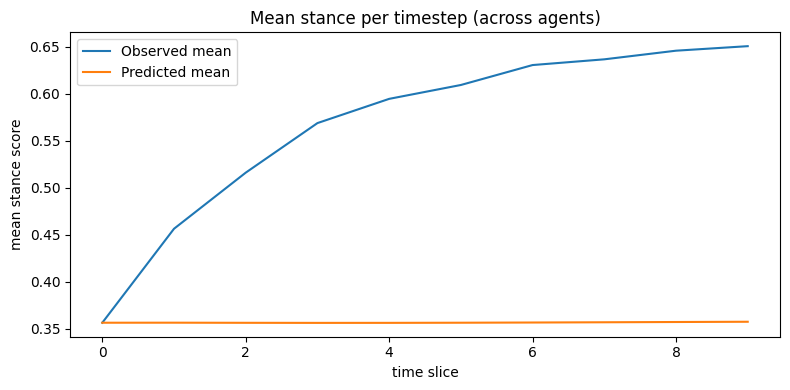

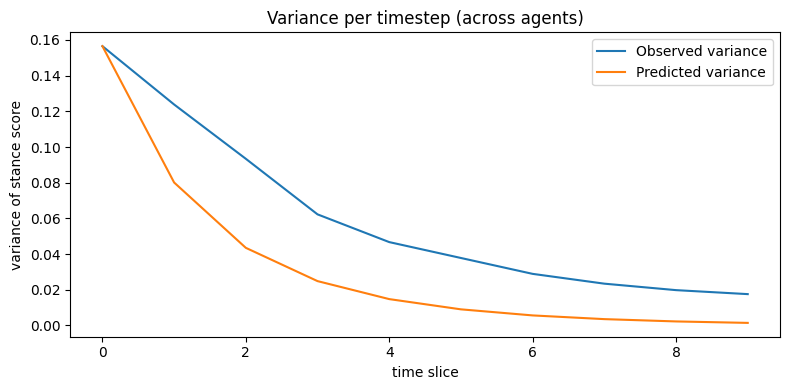

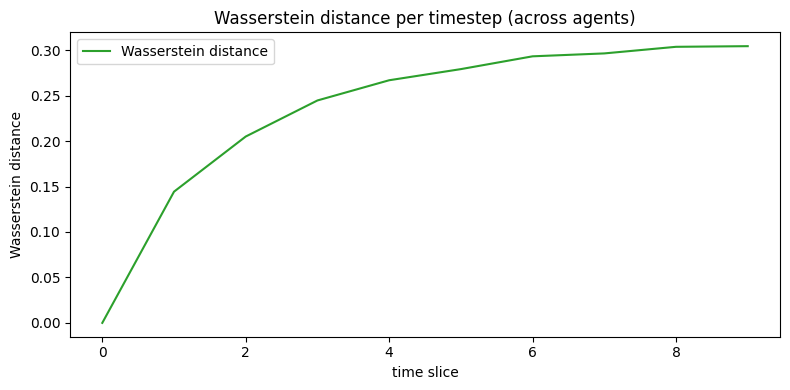

FJ adjacency


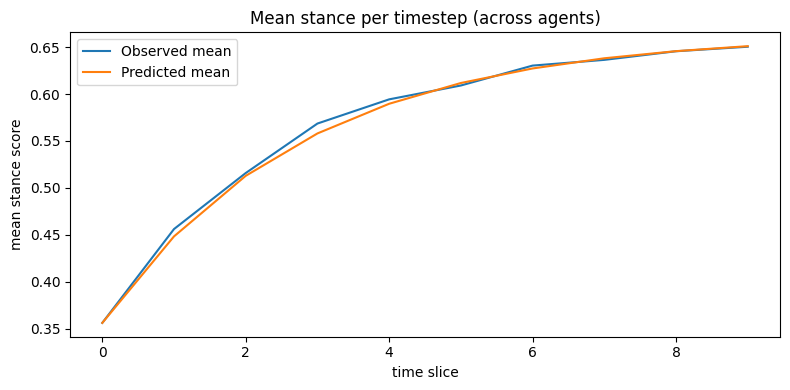

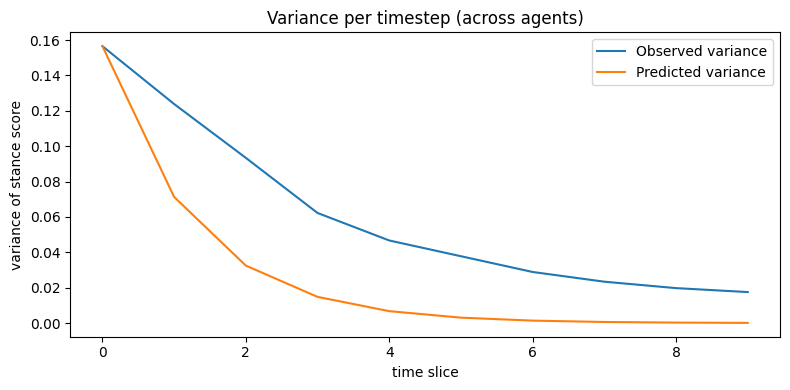

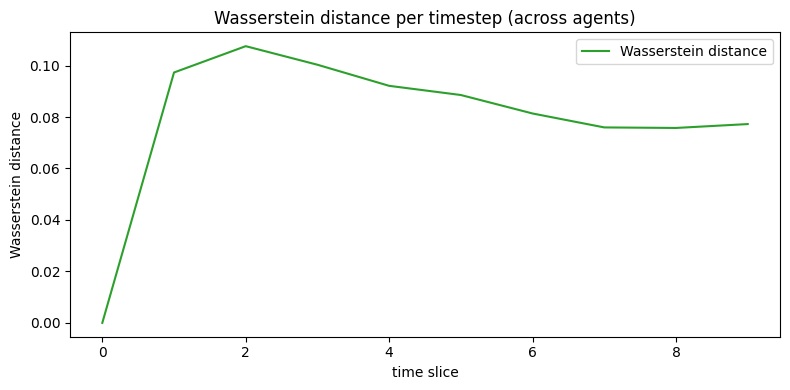

Homophily


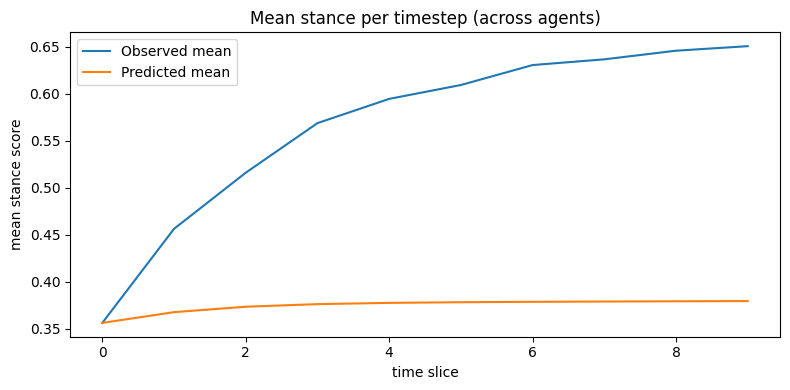

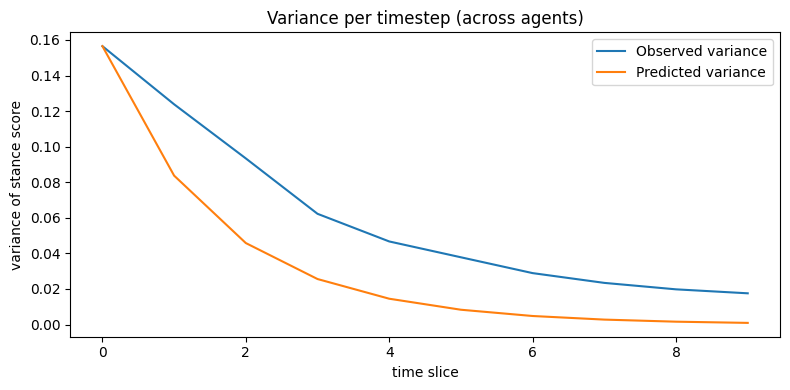

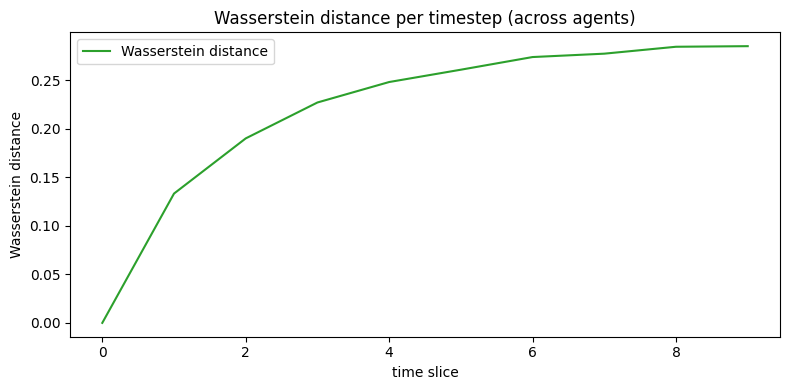

Homophily FJ Without bias


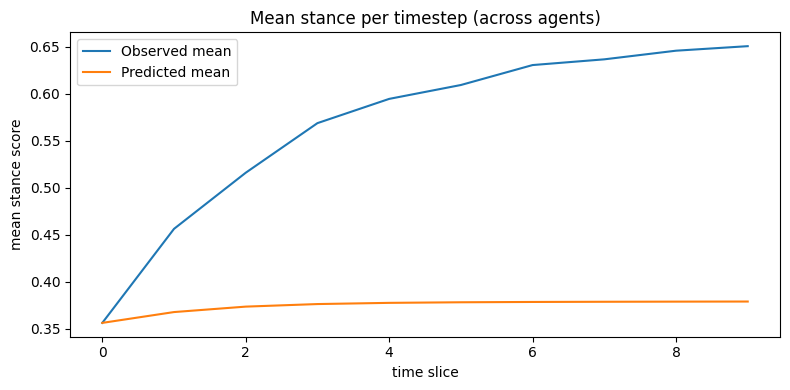

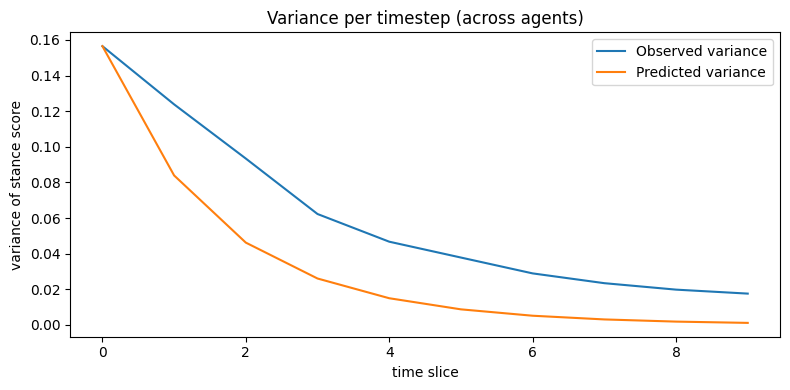

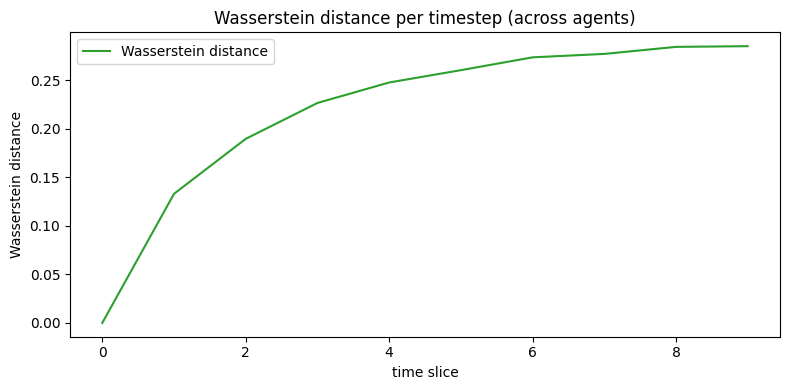

Homophily stubbornness (with bias)


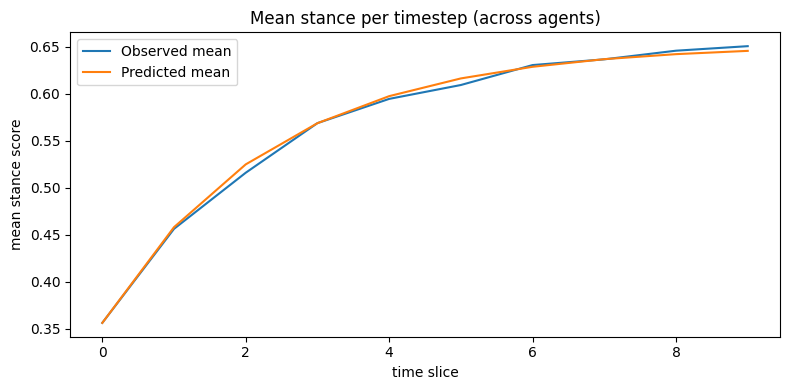

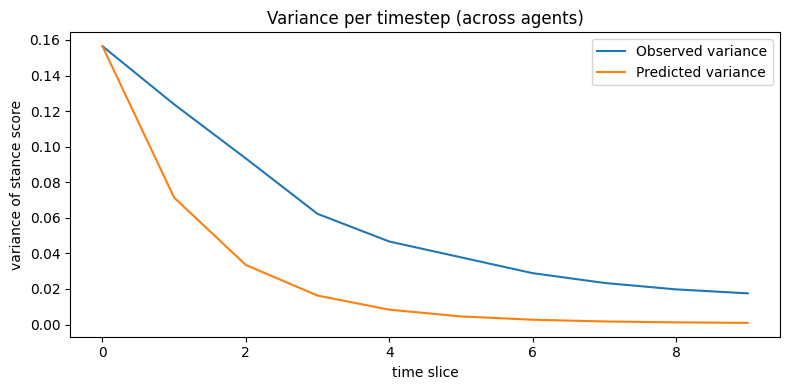

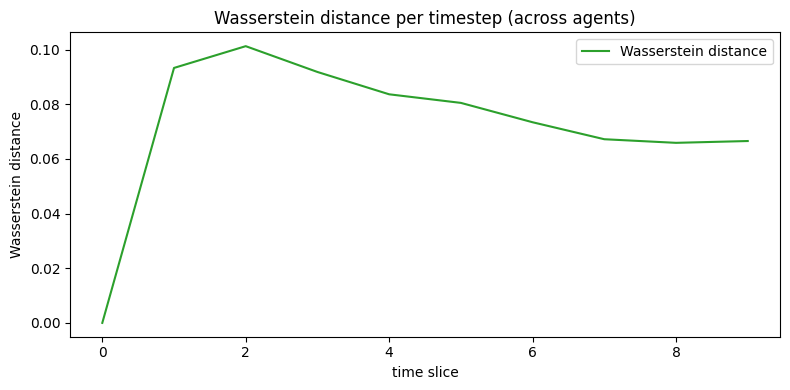

                        model  pooled_mse  transition_mse_mean  \
0    degroot_adjacency_scalar    0.022318             0.095918   
1                fj_adjacency    0.019724             0.030660   
2                   homophily    0.021848             0.087824   
3  homophily_friedkin_johnsen    0.021843             0.087829   
4      homophily_stubbornness    0.019655             0.030437   

   mean_curve_abs_error  var_curve_abs_error  wasserstein_curve_mean  
0              0.209885             0.027890                0.233829  
1              0.025838             0.032861                0.079610  
2              0.191810             0.027622                0.217821  
3              0.191912             0.027364                0.217582  
4              0.026011             0.031903                0.072368  


In [8]:
from sympy import plot


PREDICTED_TRAJ_DEGROOT = {
    rn: degroot_rollout_prediction(
        GLOBAL_W[rn],
        np.asarray(RUN_TRAJ[rn], dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
    )
    for rn in RUN_TRAJ.keys()
}
PREDICTED_TRAJ_FJ_ADJ = {
    rn: friedkin_johnsen_adjacency_rollout(
        FJ_ADJ_W[rn],
        FJ_ADJ_BIAS,
        np.asarray(RUN_TRAJ[rn], dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        FJ_ADJ_L1,
        FJ_ADJ_L2,
    )
    for rn in RUN_TRAJ.keys()
}
PREDICTED_TRAJ_HOMO = {
    rn: rollout_with_homophily(HOMOPHILY_A[rn], HOMOPHILY_GAMMA, np.asarray(RUN_TRAJ[rn], dtype=float)[0], PARAMS['rollout_horizon_cap'])
    for rn in RUN_TRAJ.keys()
}

PREDICTED_TRAJ_HOMO_FJ = {
    rn: rollout_with_homophily_friedkin_johnsen(
        HOMO_FJ_A[rn],
        HOMO_FJ_GAMMA,
        HOMO_FJ_L1,
        np.asarray(RUN_TRAJ[rn], dtype=float)[0],
        PARAMS["rollout_horizon_cap"],
        lambda_self=HOMO_FJ_LSELF
    )
    for rn in RUN_TRAJ.keys()
}

PREDICTED_TRAJ_HOMO_STUB = {
    rn: rollout_with_homophily_stubborness(
        HOMO_STUB_A[rn],
        HOMO_STUB_GAMMA,
        HOMO_STUB_BIAS,
        HOMO_STUB_L1,
        HOMO_STUB_L2,
        np.asarray(RUN_TRAJ[rn], dtype=float)[0],
        PARAMS["rollout_horizon_cap"],
        lambda_self=HOMO_STUB_LSELF
    )
    for rn in RUN_TRAJ.keys()
}

TRAIN_DEGROOT = evaluate_validation_model(
    RUN_TRAJ,
    lambda observed: degroot_rollout_prediction(
        GLOBAL_W[rn],
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
    ),
)
TRAIN_FJ_ADJ = evaluate_validation_model(
    RUN_TRAJ,
    lambda observed: friedkin_johnsen_adjacency_rollout(
        FJ_ADJ_W[rn],
        FJ_ADJ_BIAS,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        FJ_ADJ_L1,
        FJ_ADJ_L2,
    ),
)
TRAIN_HOMO = evaluate_validation_model(
    RUN_TRAJ,
    lambda observed: rollout_with_homophily(
        HOMOPHILY_A[rn],
        HOMOPHILY_GAMMA,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        lambda_self=HOMOPHILY_LAMBDA
    ),
)

TRAIN_HOMO_FJ = evaluate_validation_model(
    RUN_TRAJ,
    lambda observed: rollout_with_homophily_friedkin_johnsen(
        HOMO_FJ_A[rn],
        HOMO_FJ_GAMMA,
        HOMO_FJ_L1,
        np.asarray(observed, dtype=float)[0],
        PARAMS["rollout_horizon_cap"],
        lambda_self=HOMO_FJ_LSELF
    ),
)
TRAIN_HOMO_STUB = evaluate_validation_model(
    RUN_TRAJ,
    lambda observed: rollout_with_homophily_stubborness(
        HOMO_STUB_A[rn],
        HOMO_STUB_GAMMA,
        HOMO_STUB_BIAS,
        HOMO_STUB_L1,
        HOMO_STUB_L2,
        np.asarray(observed, dtype=float)[0],
        PARAMS["rollout_horizon_cap"],
        lambda_self=HOMO_STUB_LSELF
    ),
)

TRAIN_CURVE_HORIZON = min(
    TRAIN_DEGROOT['mean_true_stack'].shape[1],
    TRAIN_FJ_ADJ['mean_true_stack'].shape[1],
    TRAIN_HOMO['mean_true_stack'].shape[1],
    TRAIN_HOMO_FJ['mean_true_stack'].shape[1],
    TRAIN_HOMO_STUB['mean_true_stack'].shape[1],
)
print('DeGroot adjacency gamma:', DEGROOT_GAMMA)
print('FJ adjacency lambdas:', FJ_ADJ_L1, FJ_ADJ_L2)
print('FJ adjacency gamma:', FJ_ADJ_GAMMA)
print('FJ adjacency bias:', FJ_ADJ_BIAS)
print('Training metric horizon (shared):', TRAIN_CURVE_HORIZON)

print('Degroot')
plot_mean_per_timestep(
    TRAIN_DEGROOT['mean_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_DEGROOT['mean_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TRAIN_DEGROOT['var_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_DEGROOT['var_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TRAIN_DEGROOT['wasserstein_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)

print('FJ adjacency')
plot_mean_per_timestep(
    TRAIN_FJ_ADJ['mean_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_FJ_ADJ['mean_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TRAIN_FJ_ADJ['var_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_FJ_ADJ['var_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TRAIN_FJ_ADJ['wasserstein_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)

print('Homophily')
plot_mean_per_timestep(
    TRAIN_HOMO['mean_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_HOMO['mean_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TRAIN_HOMO['var_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_HOMO['var_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TRAIN_HOMO['wasserstein_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)

print("Homophily FJ Without bias")
plot_mean_per_timestep(
    TRAIN_HOMO_FJ['mean_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_HOMO_FJ['mean_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)

plot_variance_per_timestep(
    TRAIN_HOMO_FJ['var_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_HOMO_FJ['var_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)

plot_wasserstein_distance_per_timestep(
    TRAIN_HOMO_FJ['wasserstein_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON]
)

print('Homophily stubbornness (with bias)')
plot_mean_per_timestep(
    TRAIN_HOMO_STUB['mean_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_HOMO_STUB['mean_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TRAIN_HOMO_STUB['var_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_HOMO_STUB['var_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TRAIN_HOMO_STUB['wasserstein_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)

train_summary = pd.DataFrame([
    {
        'model': 'degroot_adjacency_scalar',
        'pooled_mse': DEGROOT_POOL_MSE,
        'transition_mse_mean': TRAIN_DEGROOT['transition_mse_mean'],
        'mean_curve_abs_error': TRAIN_DEGROOT['mean_curve_abs_error'],
        'var_curve_abs_error': TRAIN_DEGROOT['var_curve_abs_error'],
        'wasserstein_curve_mean': TRAIN_DEGROOT['wasserstein_curve_mean'],
    },
    {
        'model': 'fj_adjacency',
        'pooled_mse': FJ_ADJ_POOL_MSE,
        'transition_mse_mean': TRAIN_FJ_ADJ['transition_mse_mean'],
        'mean_curve_abs_error': TRAIN_FJ_ADJ['mean_curve_abs_error'],
        'var_curve_abs_error': TRAIN_FJ_ADJ['var_curve_abs_error'],
        'wasserstein_curve_mean': TRAIN_FJ_ADJ['wasserstein_curve_mean'],
    },
    {
        'model': 'homophily',
        'pooled_mse': HOMOPHILY['mse_pool'],
        'transition_mse_mean': TRAIN_HOMO['transition_mse_mean'],
        'mean_curve_abs_error': TRAIN_HOMO['mean_curve_abs_error'],
        'var_curve_abs_error': TRAIN_HOMO['var_curve_abs_error'],
        'wasserstein_curve_mean': TRAIN_HOMO['wasserstein_curve_mean'],
    },
    {
        'model': 'homophily_friedkin_johnsen',
        'pooled_mse': BEST_HOMO_FJ['mse_pool'],
        'transition_mse_mean': TRAIN_HOMO_FJ['transition_mse_mean'],
        'mean_curve_abs_error': TRAIN_HOMO_FJ['mean_curve_abs_error'],
        'var_curve_abs_error': TRAIN_HOMO_FJ['var_curve_abs_error'],
        'wasserstein_curve_mean': TRAIN_HOMO_FJ['wasserstein_curve_mean'],
    },
    {
        'model': 'homophily_stubbornness',
        'pooled_mse': BEST_HOMO_STUB['mse_pool'],
        'transition_mse_mean': TRAIN_HOMO_STUB['transition_mse_mean'],
        'mean_curve_abs_error': TRAIN_HOMO_STUB['mean_curve_abs_error'],
        'var_curve_abs_error': TRAIN_HOMO_STUB['var_curve_abs_error'],
        'wasserstein_curve_mean': TRAIN_HOMO_STUB['wasserstein_curve_mean'],
    }
])
print(train_summary)

In [9]:
# AIC/BIC ablation table on training set (degroot, stubbornness/FJ-adjacency, homophily, homophily-stubbornness).
def flatten_eval_result(eval_result):
    obs_curves = []
    pred_curves = []
    for rn in sorted(eval_result['per_run'].keys()):
        observed = np.asarray(eval_result['per_run'][rn]['observed'], dtype=float)
        predicted = np.asarray(eval_result['per_run'][rn]['predicted'], dtype=float)
        observed, predicted = align_rollout_pair(observed, predicted)
        obs_curves.append(observed.ravel())
        pred_curves.append(predicted.ravel())
    return np.concatenate(obs_curves), np.concatenate(pred_curves)

train_eval_map = {
    'degroot': (TRAIN_DEGROOT, 1),
    'stubbornness': (TRAIN_FJ_ADJ, 4),
    'homophily': (TRAIN_HOMO, 2),
    "homophily_fj": (TRAIN_HOMO_FJ, 4),
    'homophily_stubbornness': (TRAIN_HOMO_STUB, 5),
}

train_ablation_rows = []
for model_name, (eval_result, num_params) in train_eval_map.items():
    y_true_flat, y_pred_flat = flatten_eval_result(eval_result)
    mean_stats = compute_mean_prediction_error(y_true_flat, y_pred_flat, num_params=num_params)
    max_stats = compute_max_prediction_error(y_true_flat, y_pred_flat, num_params=num_params)
    train_ablation_rows.append({
        'model': model_name,
        'num_params': num_params,
        'mean_abs_error': mean_stats['mean_error'],
        'max_abs_error': max_stats['max_error'],
        'mse_aic': mean_stats['aic'],
        'mse_bic': mean_stats['bic'],
        'mae_aic': max_stats['aic'],
        'mae_bic': max_stats['bic'],
    })

train_ablation_aic_bic = pd.DataFrame(train_ablation_rows).sort_values('mse_aic').reset_index(drop=True)
print(train_ablation_aic_bic)

                    model  num_params  mean_abs_error  max_abs_error  \
0  homophily_stubbornness           5        0.105034       1.242687   
1            stubbornness           4        0.105430       1.288449   
2               homophily           2        0.244432       1.163140   
3            homophily_fj           4        0.244322       1.164396   
4                 degroot           1        0.259876       1.121391   

        mse_aic       mse_bic      mae_aic      mae_bic  
0 -29930.003372 -29894.734940  3725.422497  3760.690929  
1 -29868.562992 -29840.348246  4341.815262  4370.030009  
2 -20847.698639 -20833.591266  2588.201865  2602.309238  
3 -20842.771744 -20814.556997  2610.666852  2638.881598  
4 -20077.830237 -20070.776550  1961.141529  1968.195216  


## Validation

In [10]:
TEST_DATA_ROOT = ROOT / 'runs' / 'llama3.1' / 'climate' / 'test'
TEST_RUN_DIRS = sorted([p for p in TEST_DATA_ROOT.iterdir() if p.is_dir()])
TEST_RUN_DATA = {r.name: load_run_data(r) for r in TEST_RUN_DIRS}
TEST_RUN_TRAJ_AND_MASK = {
    rn: build_run_trajectory(
        data,
        GLOBAL_AGENT_IDS,
        target_agent_fraction=PARAMS['target_agent_fraction'],
        return_post_mask=True,
        constrain_messages=PARAMS['constrain_messages'],
    )
    for rn, data in TEST_RUN_DATA.items()
}
TEST_RUN_TRAJ = {rn: tm[0] for rn, tm in TEST_RUN_TRAJ_AND_MASK.items()}
TEST_RUN_NEIGHBORS = {rn: build_neighbors_index(data, GLOBAL_AGENT_IDS) for rn, data in TEST_RUN_DATA.items()}
TEST_RUN_NAMES = sorted(TEST_RUN_TRAJ.keys())
print('Validation runs found:', len(TEST_RUN_NAMES))

Validation runs found: 8


In [11]:
from data_prep import build_row_normalized_adjacency


TEST_DEGROOT_W = {
    rn: DEGROOT_GAMMA * build_row_normalized_adjacency(TEST_RUN_NEIGHBORS[rn], N)
    + (1.0 - DEGROOT_GAMMA) * np.eye(N, dtype=float)
    for rn in TEST_RUN_TRAJ.keys()
}

TEST_FJ_ADJ_W = {
    rn: FJ_ADJ_GAMMA * build_row_normalized_adjacency(TEST_RUN_NEIGHBORS[rn], N)
    + (1.0 - FJ_ADJ_GAMMA) * np.eye(N, dtype=float)
    for rn in TEST_RUN_TRAJ.keys()
}

TEST_HOMOPHILY_A = {
    rn: build_row_normalized_adjacency(TEST_RUN_NEIGHBORS[rn], N)
    for rn in TEST_RUN_TRAJ.keys()
}

TEST_HOMO_FJ_A = {
    rn: build_row_normalized_adjacency(TEST_RUN_NEIGHBORS[rn], N)
    for rn in TEST_RUN_TRAJ.keys()
}

TEST_HOMO_STUB_A = {
    rn: build_row_normalized_adjacency(TEST_RUN_NEIGHBORS[rn], N)
    for rn in TEST_RUN_TRAJ.keys()
}

Validation metric horizon (shared): 10
Degroot


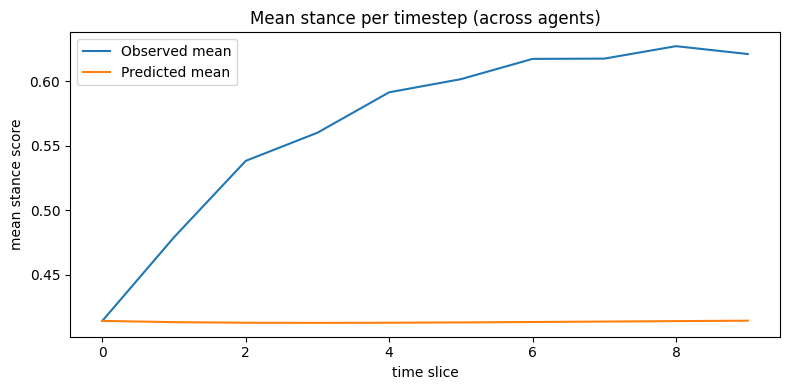

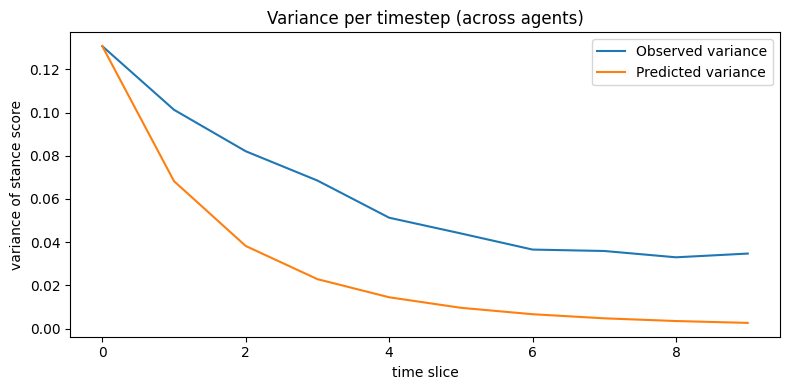

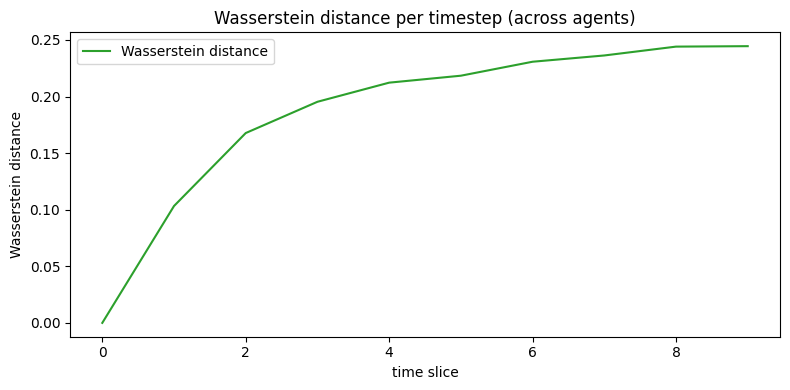

FJ adjacency


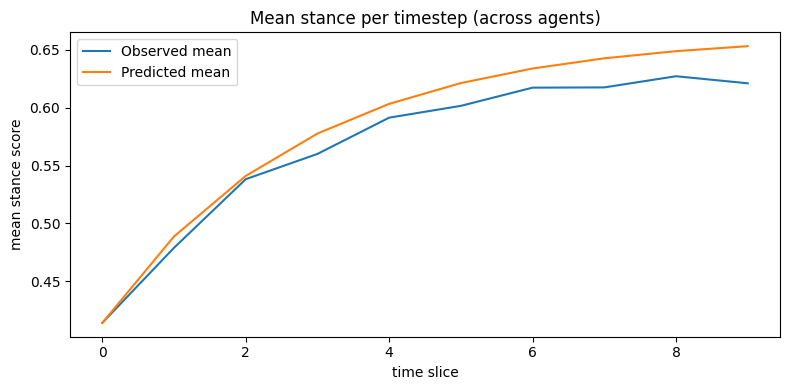

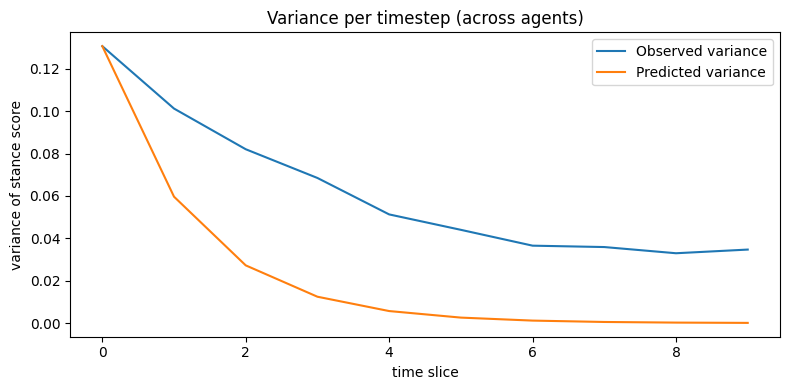

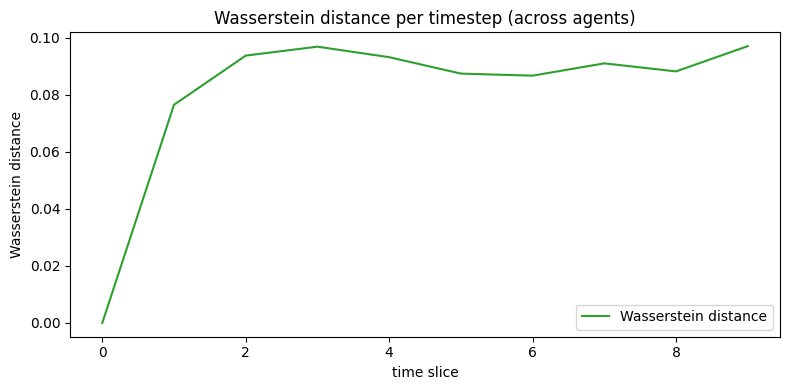

Homophily


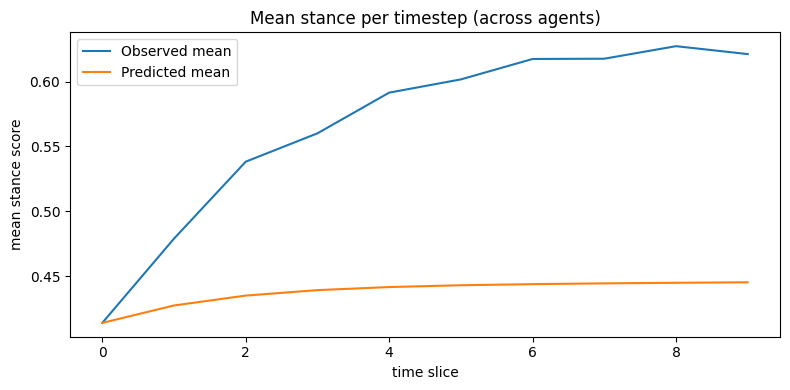

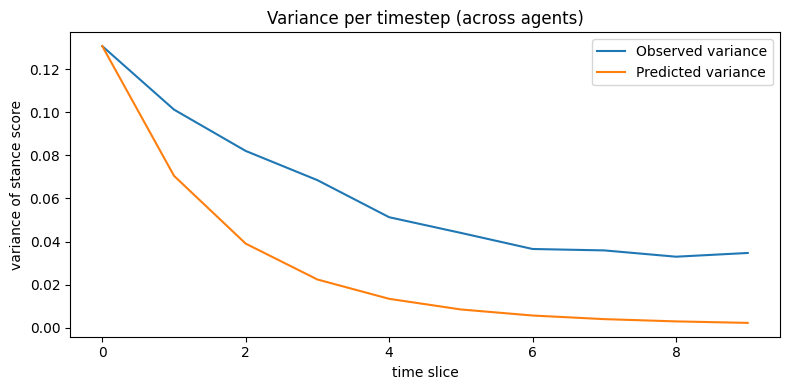

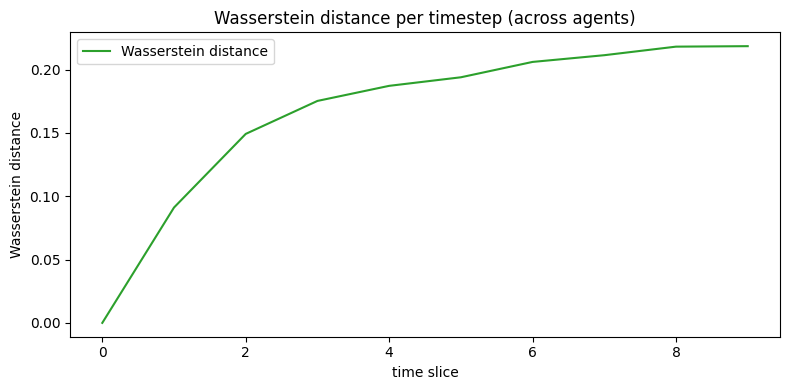

Homophily FJ (no bias)


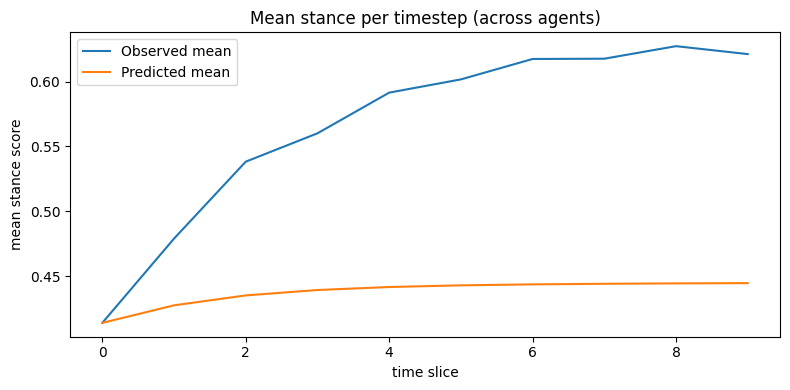

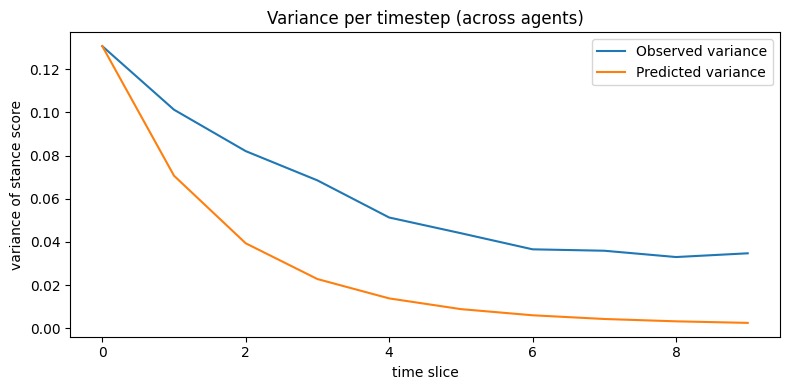

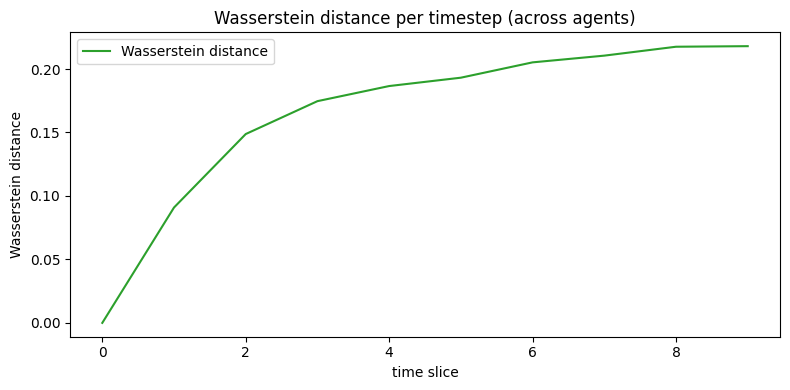

Homophily stubbornness


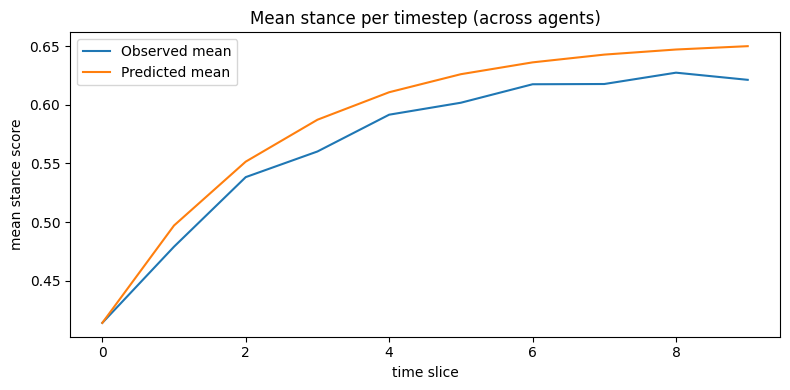

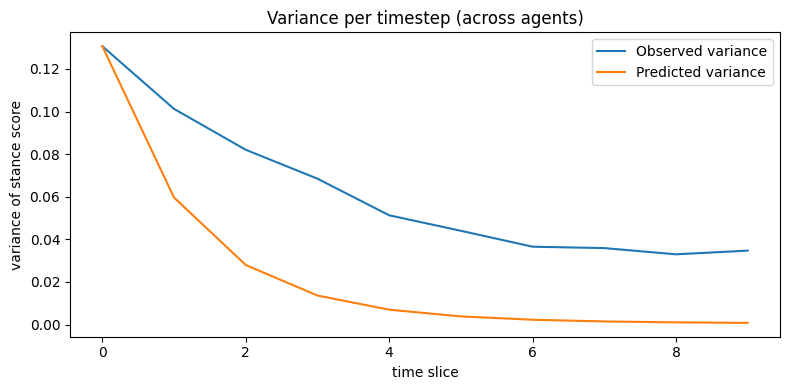

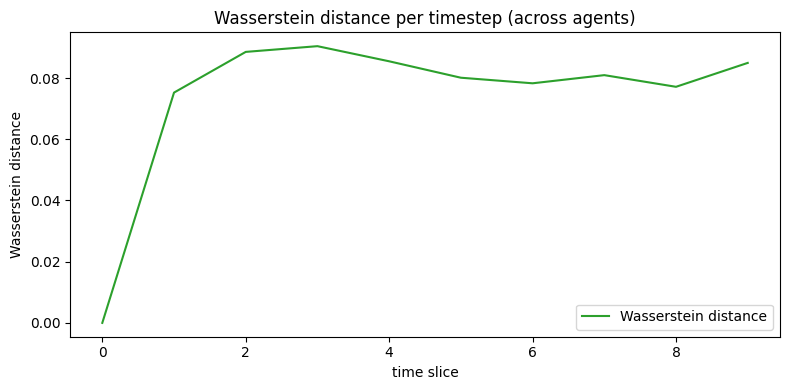

                        model  transition_mse_mean  mean_curve_abs_error  \
0                     degroot             0.074584              0.153555   
1                fj_adjacency             0.033157              0.028884   
2                   homophily             0.066372              0.129290   
3  homophily_friedkin_johnsen             0.066283              0.129420   
4      homophily_stubbornness             0.032625              0.029681   

   var_curve_abs_error  wasserstein_curve_mean  
0             0.032150                0.185250  
1             0.037839                0.081018  
2             0.032129                0.165088  
3             0.031883                0.164552  
4             0.037055                0.074103  


In [12]:
from analysis_utils import evaluate_validation_model_by_run
TEST_DEGROOT = evaluate_validation_model_by_run(
    TEST_RUN_TRAJ,
    lambda rn, observed: degroot_rollout_prediction(
        TEST_DEGROOT_W[rn],
        np.asarray(observed, dtype=float)[0],
        PARAMS["rollout_horizon_cap"],
    ),
)

TEST_FJ_ADJ = evaluate_validation_model_by_run(
    TEST_RUN_TRAJ,
    lambda rn, observed: friedkin_johnsen_adjacency_rollout(
        TEST_FJ_ADJ_W[rn],
        FJ_ADJ_BIAS,
        np.asarray(observed, dtype=float)[0],
        PARAMS["rollout_horizon_cap"],
        FJ_ADJ_L1,
        FJ_ADJ_L2,
    ),
)

TEST_HOMO = evaluate_validation_model_by_run(
    TEST_RUN_TRAJ,
    lambda rn, observed: rollout_with_homophily(
        TEST_HOMOPHILY_A[rn],
        HOMOPHILY_GAMMA,
        np.asarray(observed, dtype=float)[0],
        PARAMS["rollout_horizon_cap"],
        lambda_self=HOMOPHILY_LAMBDA,
    ),
)

TEST_HOMO_FJ = evaluate_validation_model_by_run(
    TEST_RUN_TRAJ,
    lambda rn, observed: rollout_with_homophily_friedkin_johnsen(
        TEST_HOMO_FJ_A[rn],
        HOMO_FJ_GAMMA,
        HOMO_FJ_L1,
        np.asarray(observed, dtype=float)[0],
        PARAMS["rollout_horizon_cap"],
        lambda_self=HOMO_FJ_LSELF,
    ),
)

TEST_HOMO_STUB = evaluate_validation_model_by_run(
    TEST_RUN_TRAJ,
    lambda rn, observed: rollout_with_homophily_stubborness(
        TEST_HOMO_STUB_A[rn],
        HOMO_STUB_GAMMA,
        HOMO_STUB_BIAS,
        HOMO_STUB_L1,
        HOMO_STUB_L2,
        np.asarray(observed, dtype=float)[0],
        PARAMS["rollout_horizon_cap"],
        lambda_self=HOMO_STUB_LSELF,
    ),
)
VALIDATION_CURVE_HORIZON = min(
    TEST_DEGROOT['mean_true_stack'].shape[1],
    TEST_FJ_ADJ['mean_true_stack'].shape[1],
    TEST_HOMO['mean_true_stack'].shape[1],
    TEST_HOMO_FJ['mean_true_stack'].shape[1],
    TEST_HOMO_STUB['mean_true_stack'].shape[1],
)

print('Validation metric horizon (shared):', VALIDATION_CURVE_HORIZON)

print('Degroot')
plot_mean_per_timestep(
    TEST_DEGROOT['mean_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_DEGROOT['mean_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TEST_DEGROOT['var_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_DEGROOT['var_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TEST_DEGROOT['wasserstein_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

print('FJ adjacency')
plot_mean_per_timestep(
    TEST_FJ_ADJ['mean_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_FJ_ADJ['mean_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TEST_FJ_ADJ['var_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_FJ_ADJ['var_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TEST_FJ_ADJ['wasserstein_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

print('Homophily')
plot_mean_per_timestep(
    TEST_HOMO['mean_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_HOMO['mean_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TEST_HOMO['var_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_HOMO['var_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TEST_HOMO['wasserstein_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

print("Homophily FJ (no bias)")
plot_mean_per_timestep(
    TEST_HOMO_FJ['mean_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_HOMO_FJ['mean_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

plot_variance_per_timestep(
    TEST_HOMO_FJ['var_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_HOMO_FJ['var_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

plot_wasserstein_distance_per_timestep(
    TEST_HOMO_FJ['wasserstein_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

print('Homophily stubbornness')
plot_mean_per_timestep(
    TEST_HOMO_STUB['mean_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_HOMO_STUB['mean_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TEST_HOMO_STUB['var_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_HOMO_STUB['var_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TEST_HOMO_STUB['wasserstein_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

test_summary = pd.DataFrame([
    {
        'model': 'degroot',
        'transition_mse_mean': TEST_DEGROOT['transition_mse_mean'],
        'mean_curve_abs_error': TEST_DEGROOT['mean_curve_abs_error'],
        'var_curve_abs_error': TEST_DEGROOT['var_curve_abs_error'],
        'wasserstein_curve_mean': TEST_DEGROOT['wasserstein_curve_mean'],
    },
    {
        'model': 'fj_adjacency',
        'transition_mse_mean': TEST_FJ_ADJ['transition_mse_mean'],
        'mean_curve_abs_error': TEST_FJ_ADJ['mean_curve_abs_error'],
        'var_curve_abs_error': TEST_FJ_ADJ['var_curve_abs_error'],
        'wasserstein_curve_mean': TEST_FJ_ADJ['wasserstein_curve_mean'],
    },
    {
        'model': 'homophily',
        'transition_mse_mean': TEST_HOMO['transition_mse_mean'],
        'mean_curve_abs_error': TEST_HOMO['mean_curve_abs_error'],
        'var_curve_abs_error': TEST_HOMO['var_curve_abs_error'],
        'wasserstein_curve_mean': TEST_HOMO['wasserstein_curve_mean'],
    },
    {
        'model': 'homophily_friedkin_johnsen',
        'transition_mse_mean': TEST_HOMO_FJ['transition_mse_mean'],
        'mean_curve_abs_error': TEST_HOMO_FJ['mean_curve_abs_error'],
        'var_curve_abs_error': TEST_HOMO_FJ['var_curve_abs_error'],
        'wasserstein_curve_mean': TEST_HOMO_FJ['wasserstein_curve_mean'],
    },
    {
        'model': 'homophily_stubbornness',
        'transition_mse_mean': TEST_HOMO_STUB['transition_mse_mean'],
        'mean_curve_abs_error': TEST_HOMO_STUB['mean_curve_abs_error'],
        'var_curve_abs_error': TEST_HOMO_STUB['var_curve_abs_error'],
        'wasserstein_curve_mean': TEST_HOMO_STUB['wasserstein_curve_mean'],
    },
])
print(test_summary)

In [13]:
# AIC/BIC ablation table on validation set.
validation_eval_map = {
    'degroot': (TEST_DEGROOT, 1),
    'stubbornness': (TEST_FJ_ADJ, 4),
    'homophily': (TEST_HOMO, 2),
    'homophily_fj': (TEST_HOMO_FJ, 4),
    'homophily_stubbornness': (TEST_HOMO_STUB, 5),
}

validation_ablation_rows = []
for model_name, (eval_result, num_params) in validation_eval_map.items():
    y_true_flat, y_pred_flat = flatten_eval_result(eval_result)
    mean_stats = compute_mean_prediction_error(y_true_flat, y_pred_flat, num_params=num_params)
    max_stats = compute_max_prediction_error(y_true_flat, y_pred_flat, num_params=num_params)
    validation_ablation_rows.append({
        'model': model_name,
        'num_params': num_params,
        'mean_abs_error': mean_stats['mean_error'],
        'max_abs_error': max_stats['max_error'],
        'mse_aic': mean_stats['aic'],
        'mse_bic': mean_stats['bic'],
        'mae_aic': max_stats['aic'],
        'mae_bic': max_stats['bic'],
    })

validation_ablation_aic_bic = pd.DataFrame(validation_ablation_rows).sort_values('mse_aic').reset_index(drop=True)
print(validation_ablation_aic_bic)

                    model  num_params  mean_abs_error  max_abs_error  \
0  homophily_stubbornness           5        0.103774       1.182945   
1            stubbornness           4        0.103778       1.236222   
2            homophily_fj           4        0.196500       1.045320   
3               homophily           2        0.196665       1.045105   
4                 degroot           1        0.215669       1.083206   

       mse_aic      mse_bic      mae_aic      mae_bic  
0 -9741.503437 -9711.728066   967.638984   997.414356  
1 -9695.849823 -9672.029526  1216.740371  1240.560669  
2 -7684.424402 -7660.604105   260.641586   284.461883  
3 -7684.166042 -7672.255894   255.468963   267.379112  
4 -7364.725247 -7358.770173   457.571911   463.526985  


Validation sample run: run_20260507-080811
Plot horizon (slices): 10


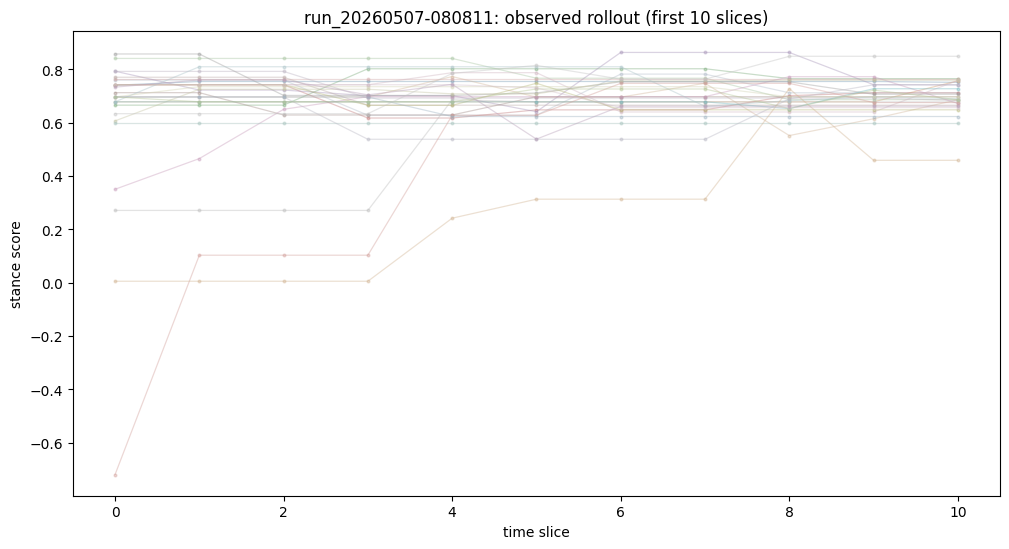

Per-trajectory diagnostics for model: degroot


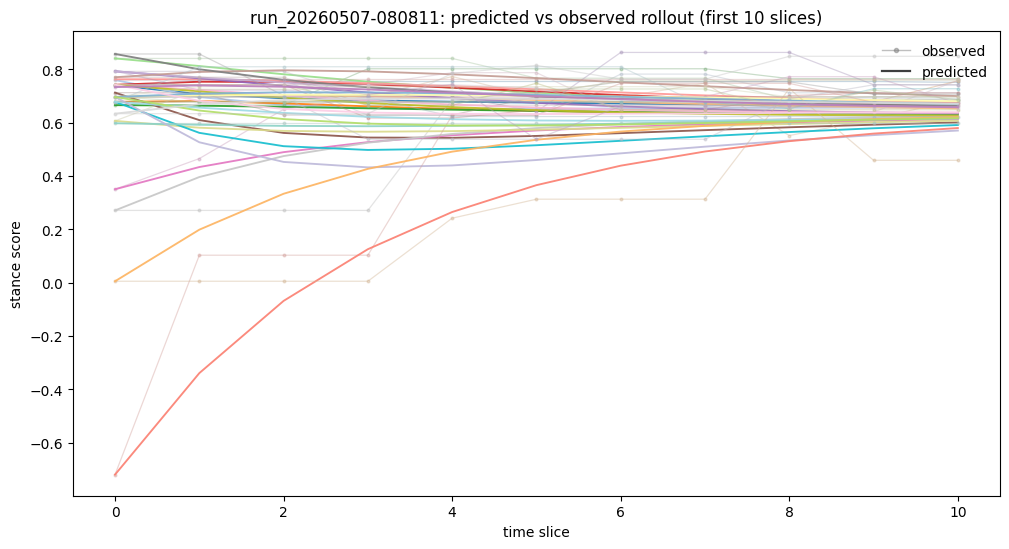

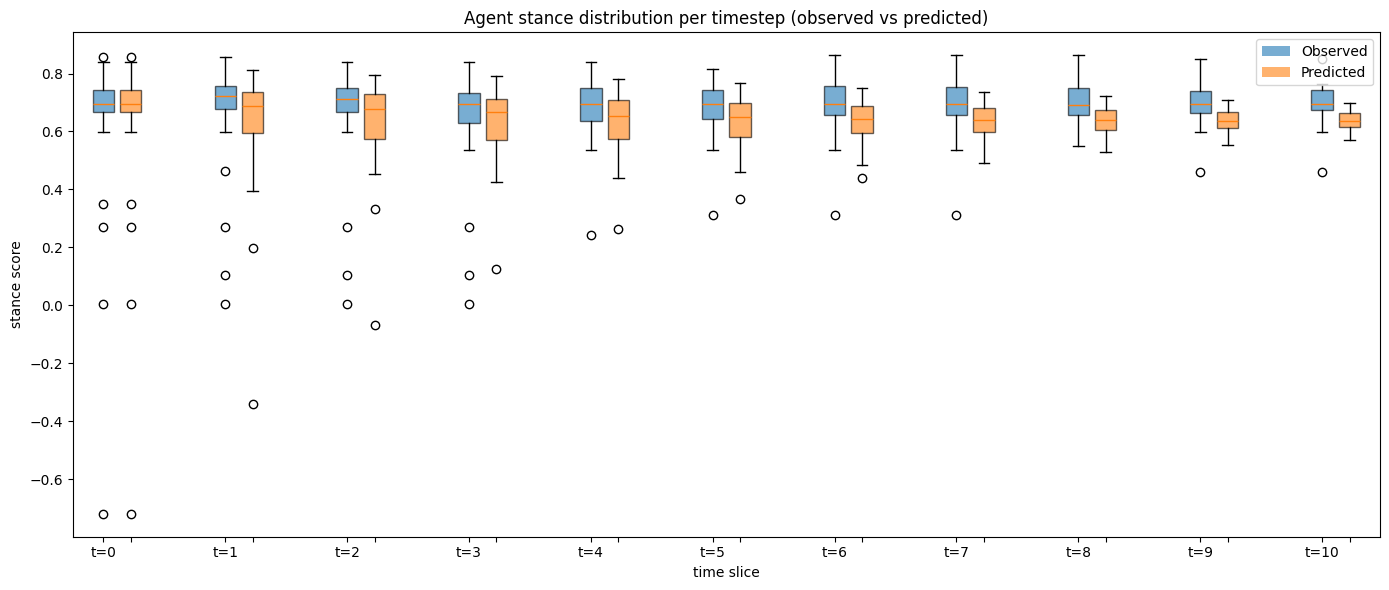

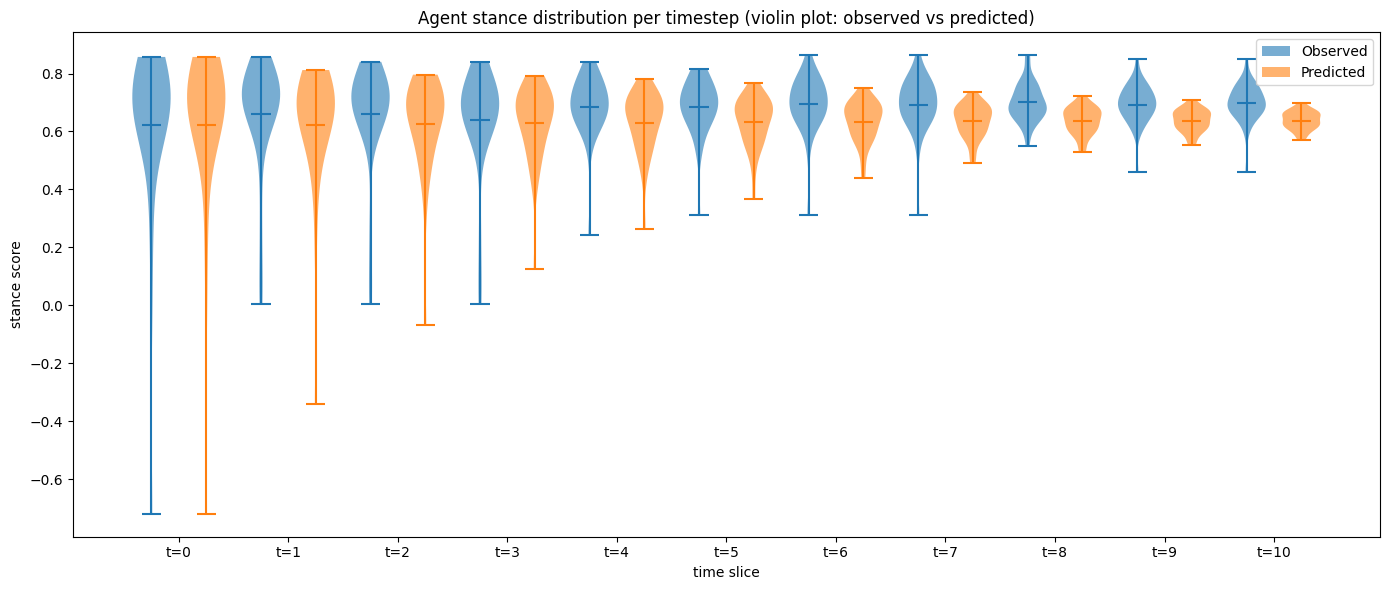

Per-trajectory diagnostics for model: stubbornness_fj_adjacency


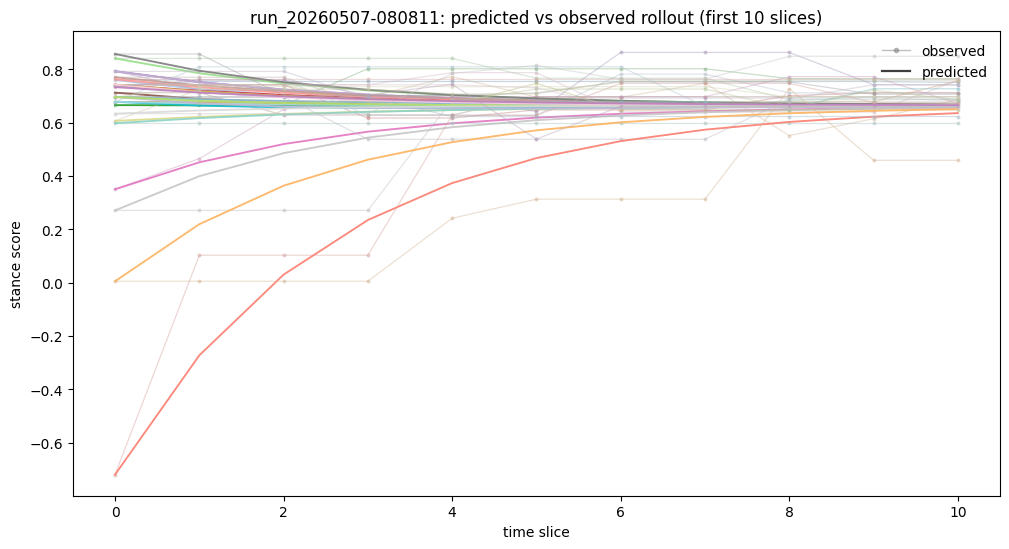

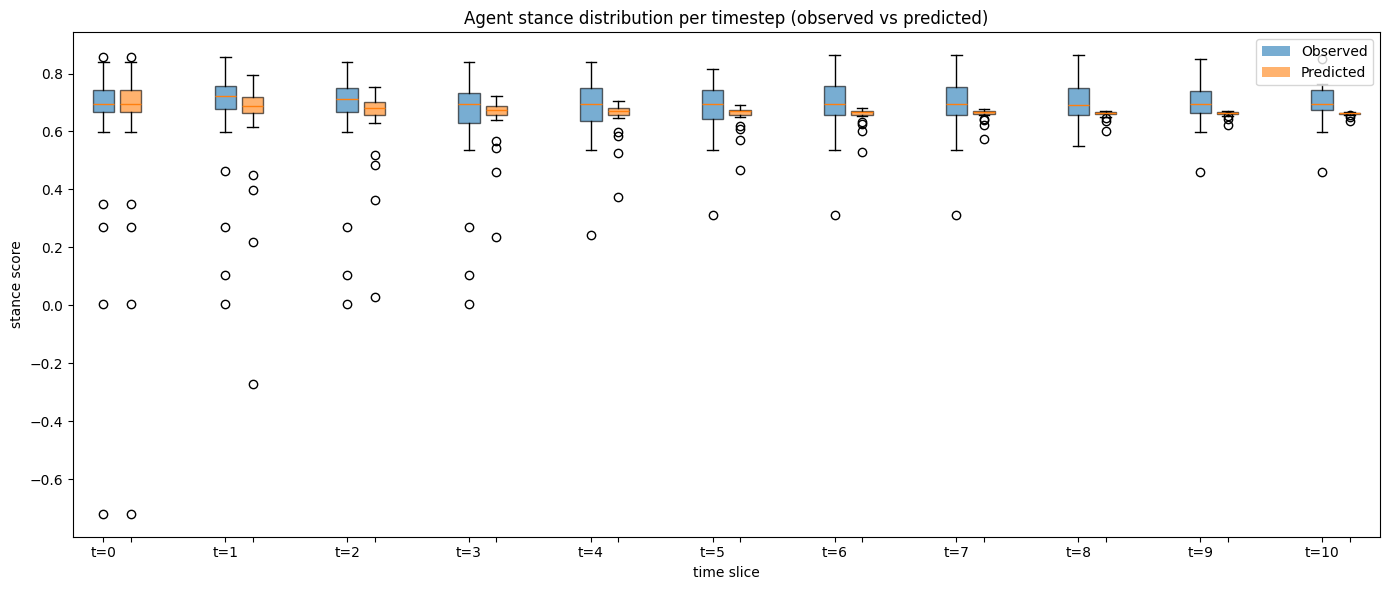

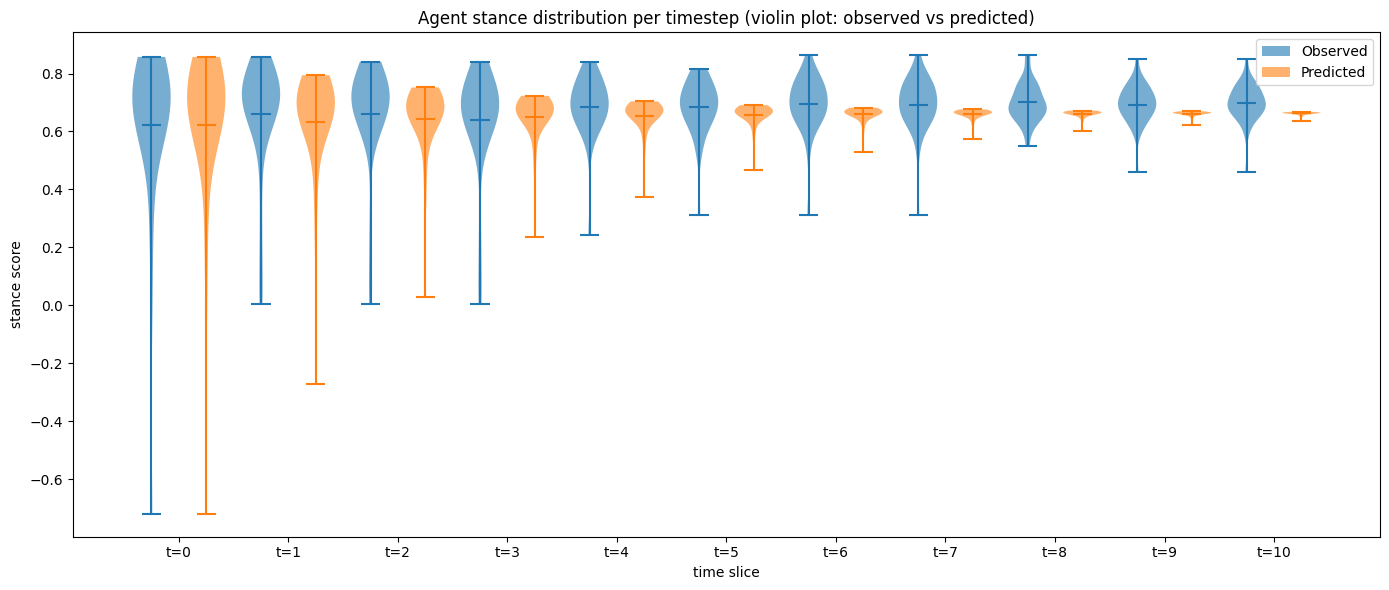

Per-trajectory diagnostics for model: homophily


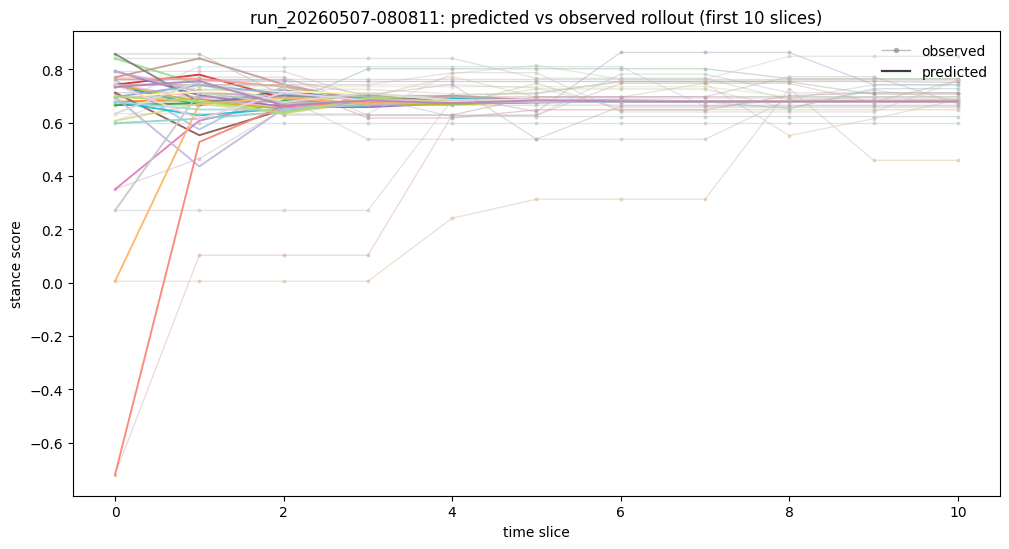

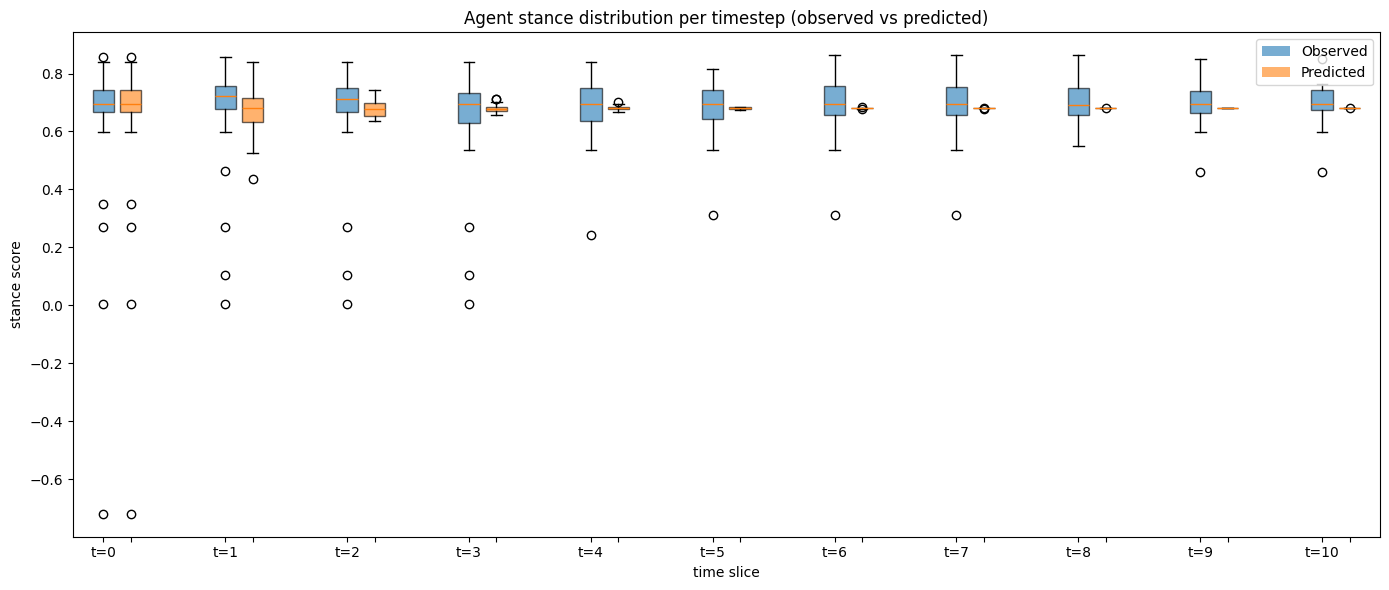

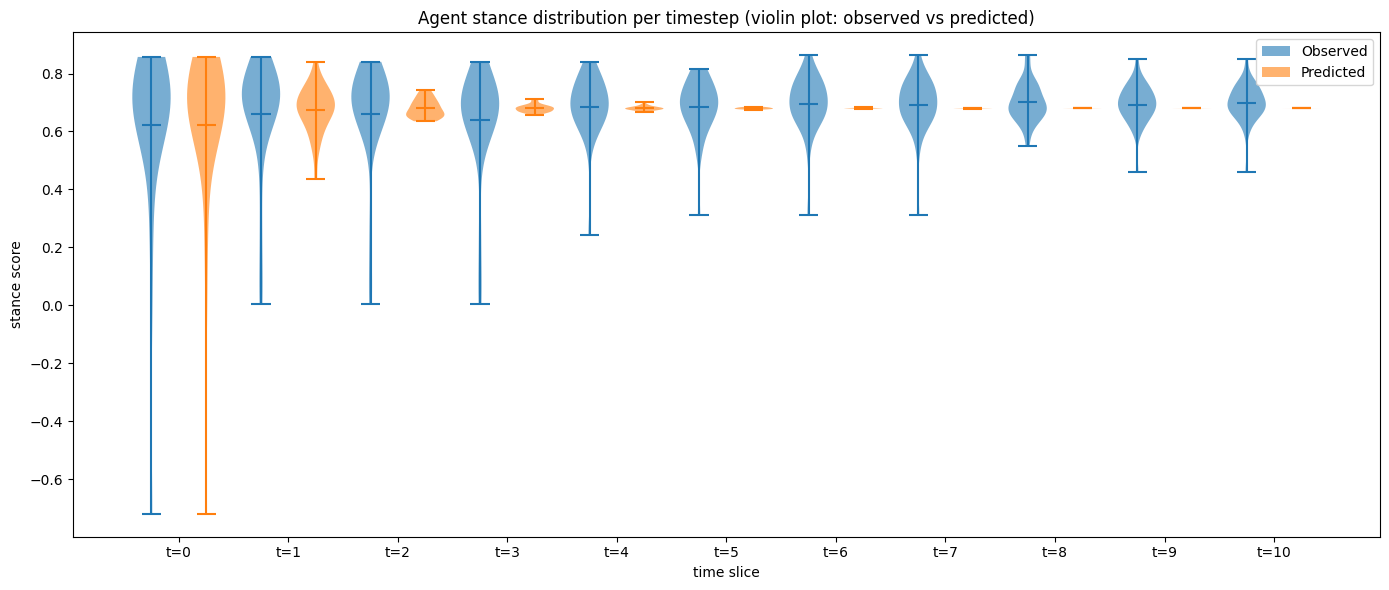

Per-trajectory diagnostics for model: homophily_stubbornness


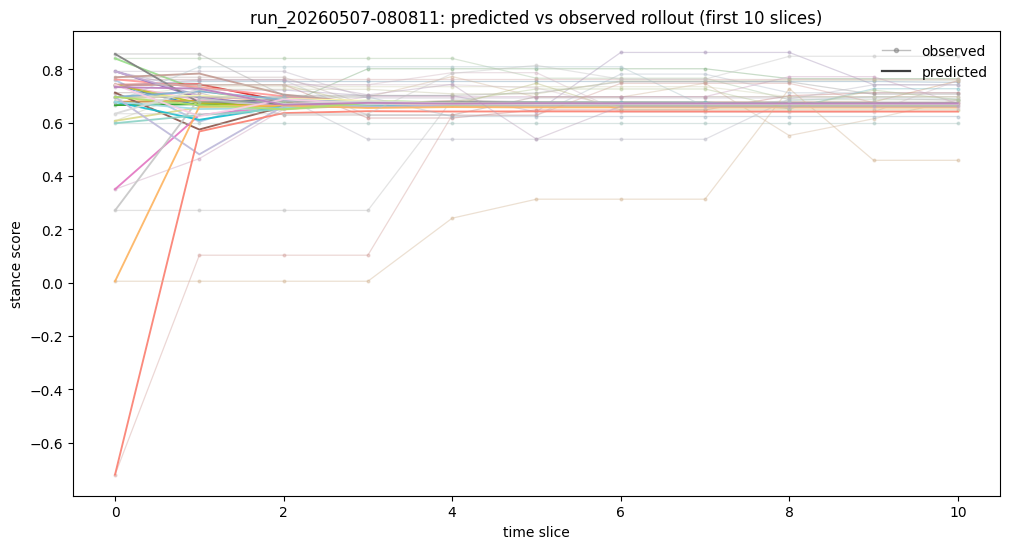

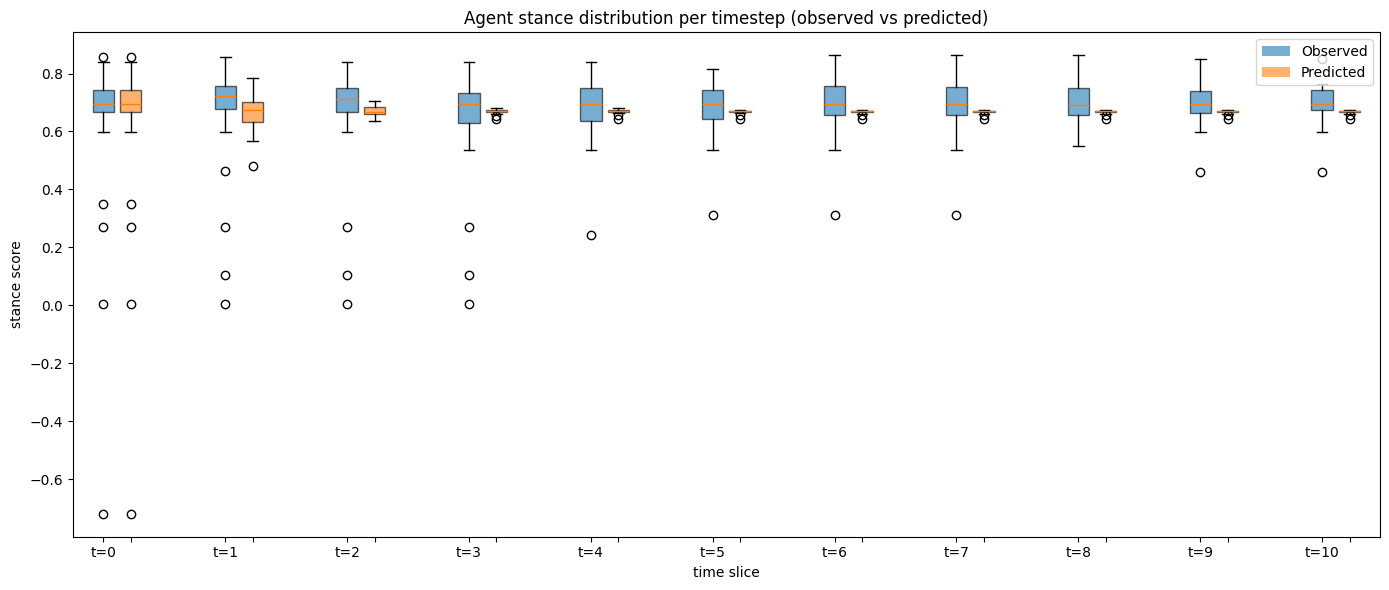

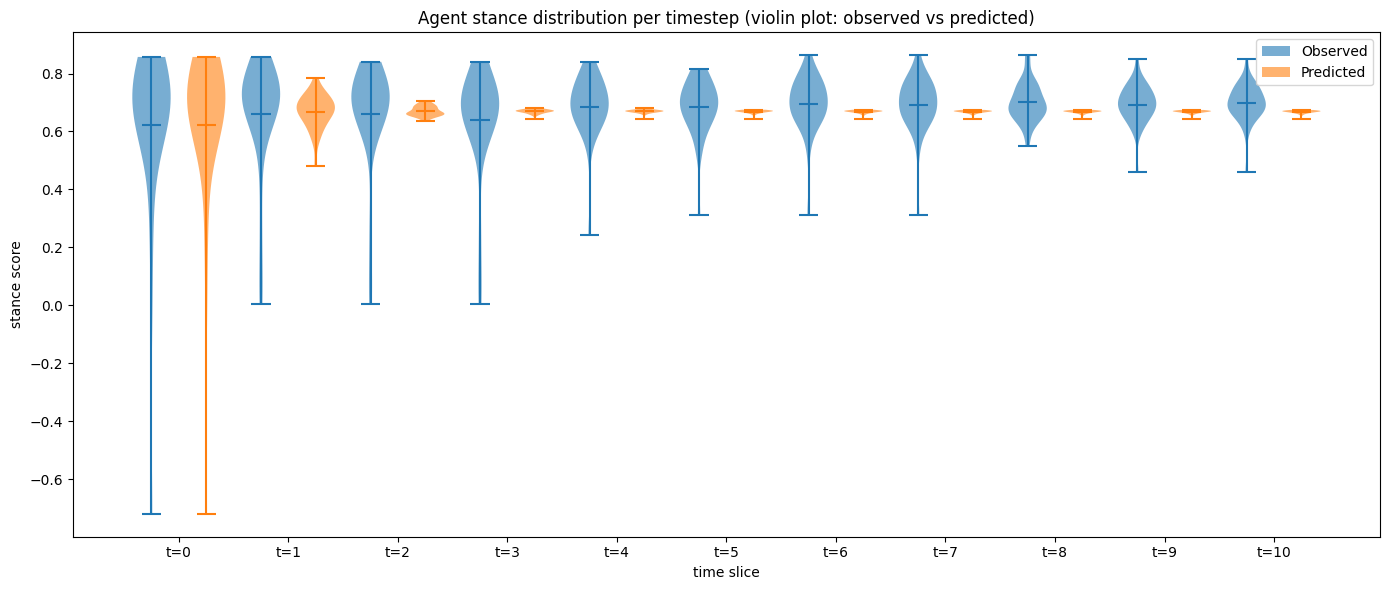

In [14]:
PREDICTED_TEST_HOMO = {
    rn: rollout_with_homophily(TEST_HOMOPHILY_A[rn], HOMOPHILY_GAMMA, np.asarray(TEST_RUN_TRAJ[rn], dtype=float)[0], PARAMS['rollout_horizon_cap'])
    for rn in TEST_RUN_TRAJ.keys()
}
PREDICTED_TEST_DEGROOT = {
    rn: degroot_rollout_prediction(TEST_DEGROOT_W[rn], np.asarray(TEST_RUN_TRAJ[rn], dtype=float)[0], PARAMS['rollout_horizon_cap'])
    for rn in TEST_RUN_TRAJ.keys()
}
PREDICTED_TEST_FJ_ADJ = {
    rn: friedkin_johnsen_adjacency_rollout(
        TEST_FJ_ADJ_W[rn],
        FJ_ADJ_BIAS,
        np.asarray(TEST_RUN_TRAJ[rn], dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        FJ_ADJ_L1,
        FJ_ADJ_L2,
    )
    for rn in TEST_RUN_TRAJ.keys()
}
PREDICTED_TEST_HOMO_STUB = {
    rn: rollout_with_homophily_stubborness(
        TEST_HOMO_STUB_A[rn],
        HOMO_STUB_GAMMA,
        HOMO_STUB_BIAS,
        HOMO_STUB_L1,
        HOMO_STUB_L2,
        np.asarray(TEST_RUN_TRAJ[rn], dtype=float)[0],
        PARAMS["rollout_horizon_cap"],
    )
    for rn in TEST_RUN_TRAJ.keys()
}

run_id = max(TEST_RUN_NAMES, key=lambda rn: np.asarray(TEST_RUN_TRAJ[rn], dtype=float).shape[0])
plot_horizon = min(
    10,
    np.asarray(TEST_RUN_TRAJ[run_id], dtype=float).shape[0] - 1,
    np.asarray(PREDICTED_TEST_HOMO[run_id], dtype=float).shape[0] - 1,
    np.asarray(PREDICTED_TEST_DEGROOT[run_id], dtype=float).shape[0] - 1,
    np.asarray(PREDICTED_TEST_FJ_ADJ[run_id], dtype=float).shape[0] - 1,
    np.asarray(PREDICTED_TEST_HOMO_STUB[run_id], dtype=float).shape[0] - 1,
)

print('Validation sample run:', run_id)
print('Plot horizon (slices):', plot_horizon)

plot_observed_trajectories(run_id, TEST_RUN_TRAJ[run_id], GLOBAL_AGENT_IDS, plot_horizon)

per_model_predictions = [
    ('degroot', PREDICTED_TEST_DEGROOT[run_id]),
    ('stubbornness_fj_adjacency', PREDICTED_TEST_FJ_ADJ[run_id]),
    ('homophily', PREDICTED_TEST_HOMO[run_id]),
    ('homophily_stubbornness', PREDICTED_TEST_HOMO_STUB[run_id]),
]

for model_name, predicted_curve in per_model_predictions:
    print(f'Per-trajectory diagnostics for model: {model_name}')
    plot_predicted_vs_observed(
        run_id,
        TEST_RUN_TRAJ[run_id],
        predicted_curve,
        GLOBAL_AGENT_IDS,
        plot_horizon,
    )

    observed_aligned, predicted_aligned = align_rollout_pair(
        np.asarray(TEST_RUN_TRAJ[run_id], dtype=float),
        np.asarray(predicted_curve, dtype=float),
    )
    observed_aligned = observed_aligned[: plot_horizon + 1]
    predicted_aligned = predicted_aligned[: plot_horizon + 1]

    plot_box_per_timestep(observed_aligned, predicted_aligned)
    plot_violin_per_timestep(observed_aligned, predicted_aligned)